In [81]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")
print(len(chars))
ergo_chords=keymap.generate_ergonomic_chords(3)
print(len(ergo_chords))

POP_SIZE =300  # Population size for genetic algorithm
GENS = 150  # Number of generations
MUTATION_RATE = 0.5  # Probability of mutation
MAX_MUTATION=10
layout_cost=lambda layout: optimization.layout_cost(layout,char_freqs,bigram_matrix,ergo_chords)



36
92


0.10164935349460888: 100%|██████████| 150/150 [02:06<00:00,  1.18it/s]


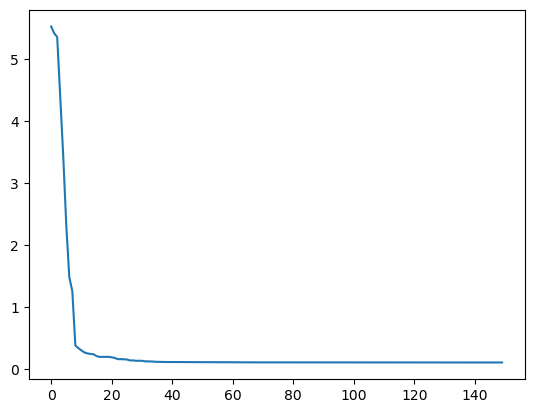

In [83]:
import random
best_score = []
population = [keymap.generate_random_layout(len(ergo_chords)) for _ in range(POP_SIZE)]

progress=tqdm(range(GENS))
for _ in progress:
    population = sorted(population, key=layout_cost) 
    progress.set_description(str(layout_cost(population[0])))
    
        # Rank by cost
    best_score.append(layout_cost(population[0]))
    next_gen = population[:POP_SIZE // 2]  # Keep best 50%
    
    while len(next_gen) < POP_SIZE:
        p1, p2 = random.sample(population[:POP_SIZE // 4], 2)  # Select top candidates
        child = keymap.crossover(p1.copy(), p2)
        child = keymap.mutate(child,MUTATION_RATE,MAX_MUTATION)
        next_gen.append(child)
    
    population = next_gen  # Move tonext generation

best_layout=sorted(population, key=layout_cost)[0]  # Best layout
plt.plot(best_score)

Text(0.5, 1.0, '0.10164935349460888')

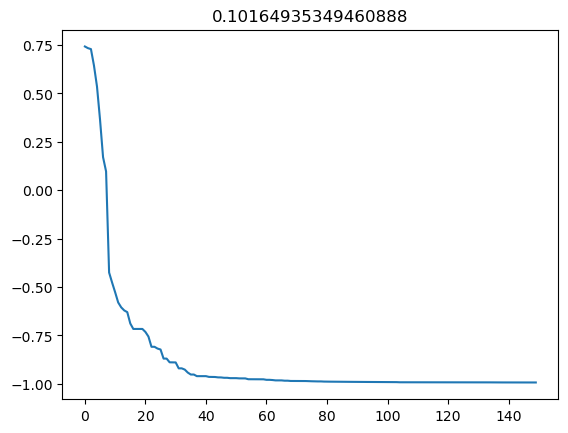

In [84]:
plt.plot(np.log10(best_score))
plt.title(best_score[-1])

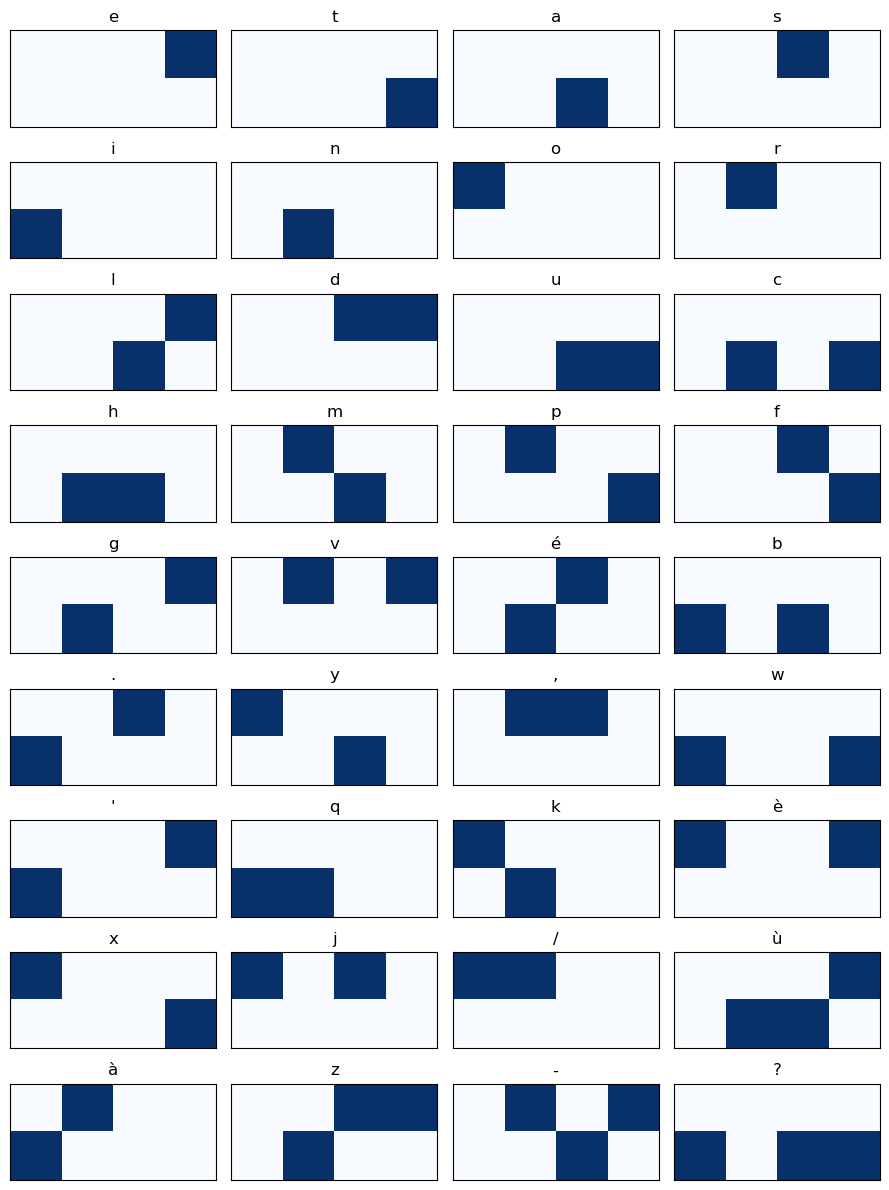

In [85]:
# keymap.plot_layout(best_layout,ergo_chords,chars)
keymap.plot_layout_nicer(best_layout,ergo_chords,chars)